### Program 1

imports

In [346]:
import numpy
import keras
from math import sqrt
from pathlib import Path
from keras import layers, Input, Model, optimizers
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
import numpy as np

plt.style.use('dark_background')

OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)
DATASET_FILES = [Path(f"../resources/dane{i}.txt") for i in range(1, 9)]
number_of_epochs = 80
random_state = 42


encapsulated pipeline

In [355]:
def load_data(file_path: Path):
    with open(file_path) as file:
        data = file.readlines()

    x_data, y_data = zip(*[map(float, line.split()) for line in data])
    return x_data, y_data


def split_data(x_data, y_data):
    X_train, X_test, y_train, y_test = train_test_split(
        x_data, y_data, test_size=0.2, random_state=random_state
    )
    return X_train, X_test, y_train, y_test


def plot_input_data(x_data, y_data, X_train, X_test, y_train, y_test, file_name):
    _, (test_plot, train_plot, org_plot) = plt.subplots(1, 3, figsize=(15, 4))

    test_plot.scatter(X_test, y_test)
    test_plot.set_title(f"{file_name} | test dataset")
    train_plot.scatter(X_train, y_train)
    train_plot.set_title(f"{file_name} | train dataset")
    org_plot.scatter(x_data, y_data)
    org_plot.set_title(f"{file_name} | original dataset")

    plt.tight_layout()
    plt.show()


def nest_and_put_into_np(flat_arr: list):
    nested_arr = []
    for element in flat_arr:
        nested_arr.append([element])
    return np.array(nested_arr, dtype="float32")


def format_input_data(X_train, X_test, y_train, y_test):
    X_train_f = nest_and_put_into_np(X_train)
    X_test_f = nest_and_put_into_np(X_test)
    y_train_f = nest_and_put_into_np(y_train)
    y_test_f = nest_and_put_into_np(y_test)

    return X_train_f, X_test_f, y_train_f, y_test_f


def build_regression_model():
    inputs = Input(shape=(1,), name="input_features")
    x = layers.Dense(12, activation="relu", name="hidden_layer_1")(inputs)
    x = layers.Dense(6, activation="relu", name="hidden_layer_2")(x)
    outputs = layers.Dense(1, name="predicted_value")(x)

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="regression_model"
    )

    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.01),
        loss="mse",
        metrics=["mse"]
    )

    return model


def train(model, X_train_f, y_train_f):
    # batch_size = int(sqrt(len(X_train_f)))
    batch_size = int(len(X_train_f) / 4)

    training_history = model.fit(
        X_train_f,
        y_train_f,
        epochs=number_of_epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=0
    )
    return training_history


def predict(model, X_test_f):
    return model.predict(X_test_f, verbose=0)


def run_pipeline(file_path: Path, plot_single_dataset=False):
    x_data, y_data = load_data(file_path)
    X_train, X_test, y_train, y_test = split_data(x_data, y_data)

    if plot_single_dataset:
        plot_input_data(x_data, y_data, X_train, X_test, y_train, y_test, file_path.name)

    X_train_f, X_test_f, y_train_f, y_test_f = format_input_data(X_train, X_test, y_train, y_test)
    model = build_regression_model()
    training_history = train(model, X_train_f, y_train_f)
    predictions = predict(model, X_test_f)

    mse_values: list[float] = training_history.history["mse"]
    last_mse = mse_values[len(mse_values) - 1]
    first_mse = mse_values[0]
    test_mae = round(mean_absolute_error(y_test, predictions), 3)

    return {
        "file_name": file_path.name,
        "x_data": x_data,
        "y_data": y_data,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "X_test_f": X_test_f.flatten(),
        "y_test_f": y_test_f.flatten(),
        "predictions": predictions.flatten(),
        "training_history": training_history.history,
        "model": model,
        "test_mae": test_mae,
        "first_mse": first_mse,
        "last_mse": last_mse,
    }


def plot_all_results(results):
    fig, axes = plt.subplots(2, 4, figsize=(22, 10), constrained_layout=True)

    for ax, result in zip(axes.flat, results):
        sorted_indices = np.argsort(result["X_test_f"])
        ax.scatter(result["X_test_f"], result["y_test_f"], c="green")
        ax.plot(
            result["X_test_f"][sorted_indices],
            result["predictions"][sorted_indices],
            c="red"
        )

        legend_elements = [
                  Line2D([0], [0], marker='o', color='green', label='true value', markersize=8),
                  Line2D([0], [0], marker='o', color='red', label='predicted value', markersize=8),
            ]

        ax.legend(handles=legend_elements, loc="upper right", fontsize=8)
        ax.set_title(f"{result['file_name']} | MAE {result['test_mae']}")

    plt.show()
    fig.savefig(OUTPUT_DIR / "all_results_comparison.png")


def plot_all_losses(results):
    fig, axes = plt.subplots(2, 4, figsize=(22, 10), constrained_layout=True)

    for ax, result in zip(axes.flat, results):
        validation_loss_values = result["training_history"]["loss"]
        ax.plot(range(1, len(validation_loss_values) + 1), validation_loss_values)
        ax.set_xlabel("epoch")
        ax.set_ylabel("loss")
        ax.set_title(result["file_name"])

    plt.show()
    fig.savefig(OUTPUT_DIR / "all_losses.png")


def print_results_summary(results):
    for result in results:
        print(f"mse improvement between first and last epoch | first_mse: {result['first_mse']}, last_mse: {result['last_mse']}, delta: {result['first_mse'] - result['last_mse']}")

        initial_loss = round(result["training_history"]["mse"][0], 5)
        final_loss = round(result["training_history"]["mse"][-1], 5)

        print(
            f"For the regression problem in file {result['file_name']} a network with hidden layers has been chosen. "
            "The layers use RELU activation function to prevent the linearity problem. In the training the ADAM function was used for recalculation of neurons weights. The training "
            f"consisted of {number_of_epochs} epochs and additionally the batch size was set as one-forth of the train dataset size.\n"
            ""
            "Configuration has yielded following results:\n"
            f"- The mean absolute error of training test is {result['test_mae']}\n"
            f"- The validation loss decreased from {initial_loss} observed after first epoch to {final_loss} observed after {number_of_epochs}th epoch."
        )


run the pipeline for 8 consecutive files

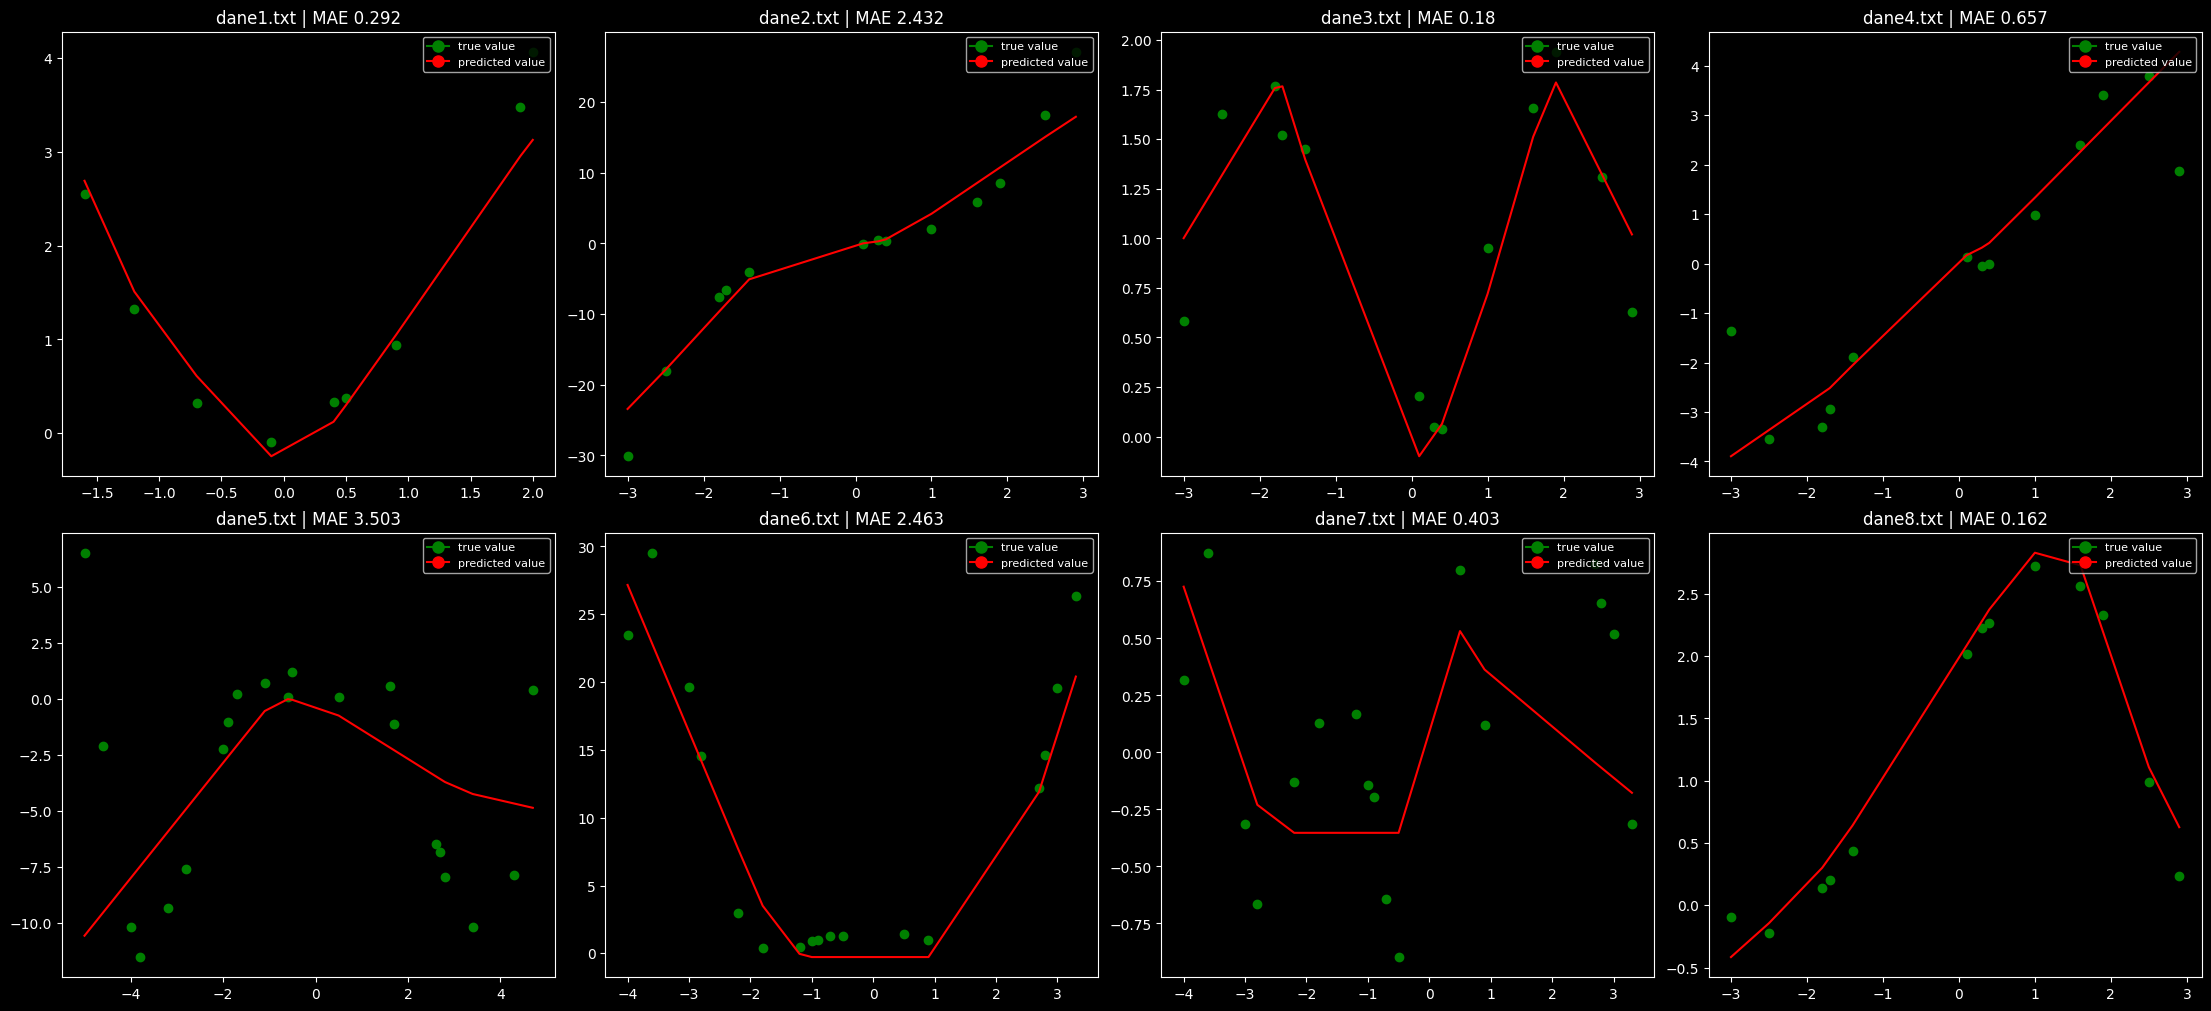

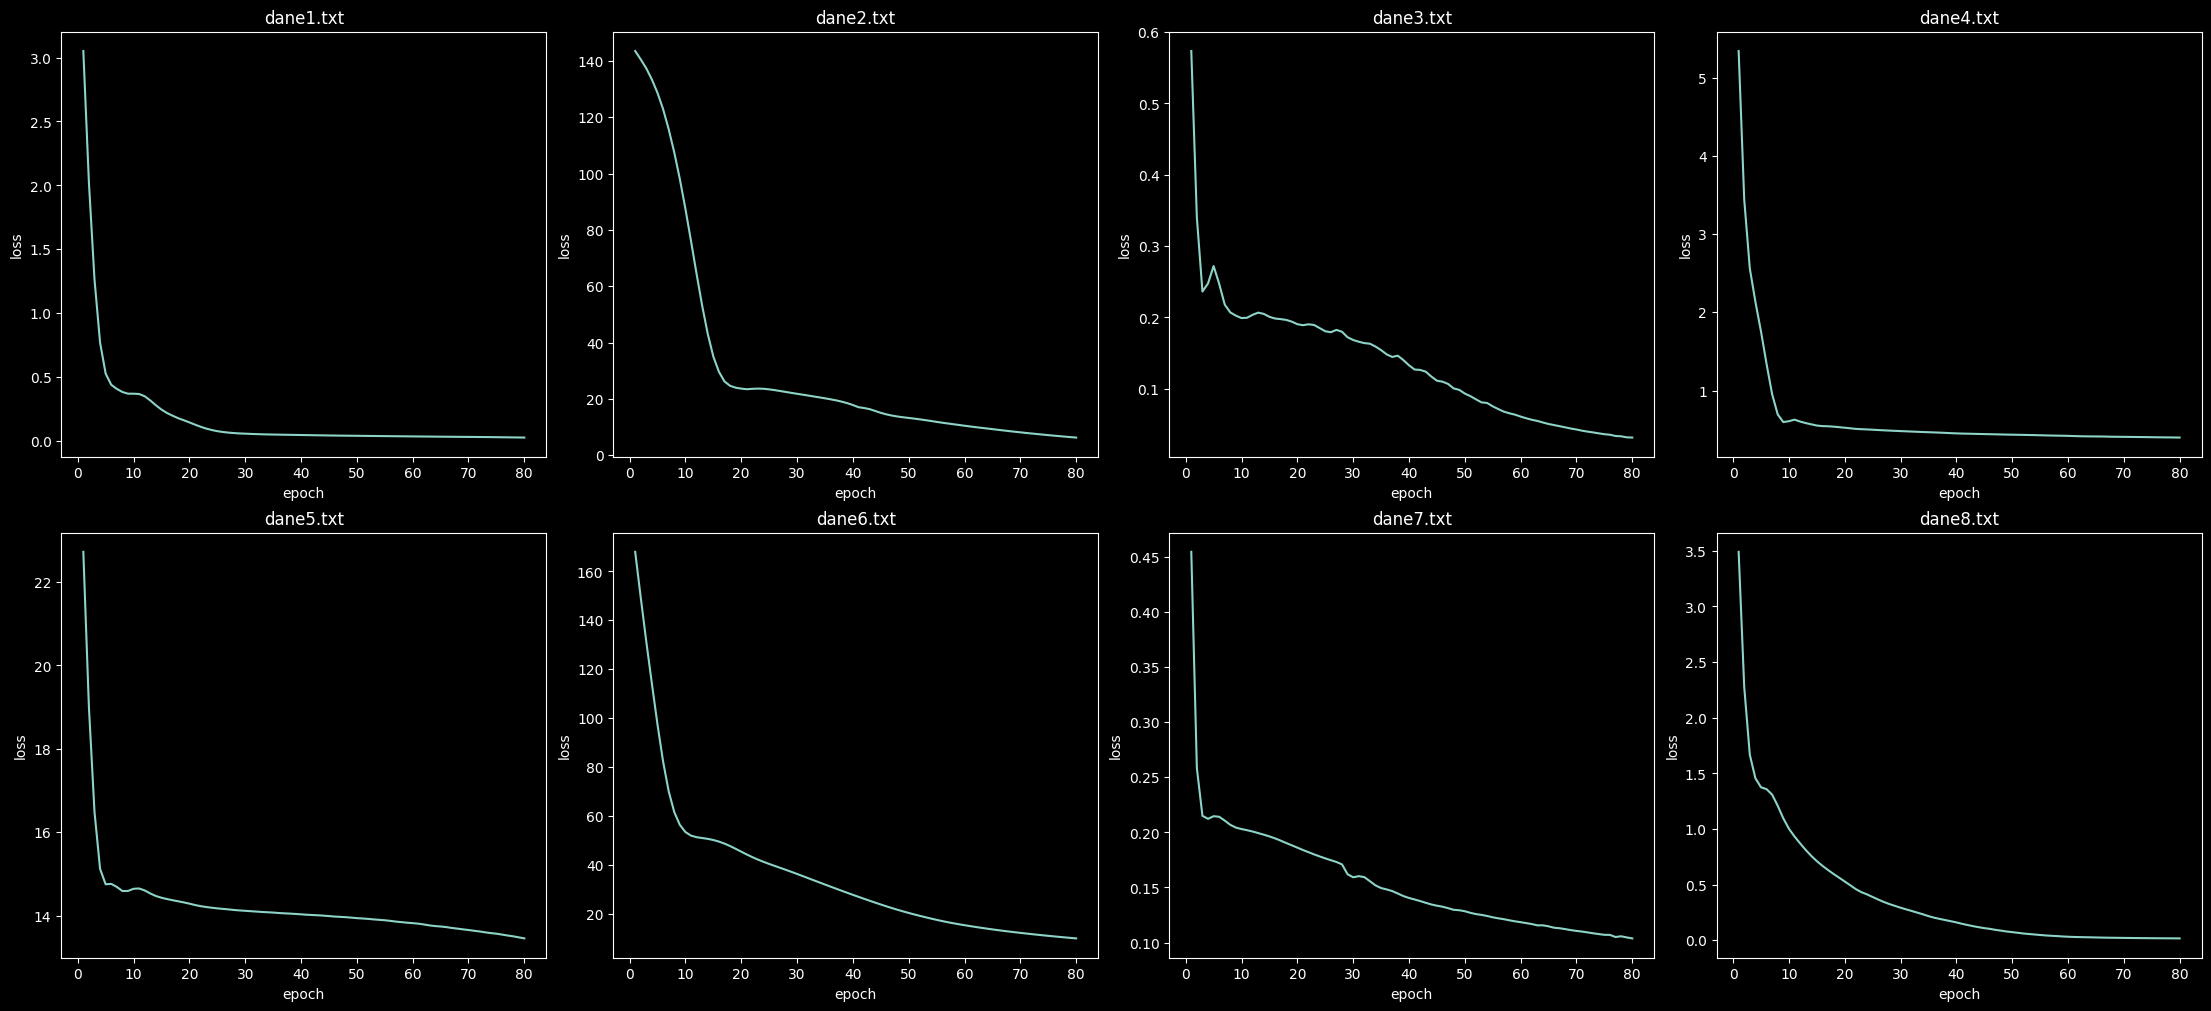

mse improvement between first and last epoch | first_mse: 3.052107334136963, last_mse: 0.024675868451595306, delta: 3.0274314656853676
For the regression problem in file dane1.txt a network with hidden layers has been chosen. The layers use RELU activation function to prevent the linearity problem. In the training the ADAM function was used for recalculation of neurons weights. The training consisted of 80 epochs and additionally the batch size was set as one-forth of the train dataset size.
Configuration has yielded following results:
- The mean absolute error of training test is 0.292
- The validation loss decreased from 3.05211 observed after first epoch to 0.02468 observed after 80th epoch.
mse improvement between first and last epoch | first_mse: 143.5474090576172, last_mse: 6.273642063140869, delta: 137.27376699447632
For the regression problem in file dane2.txt a network with hidden layers has been chosen. The layers use RELU activation function to prevent the linearity problem.

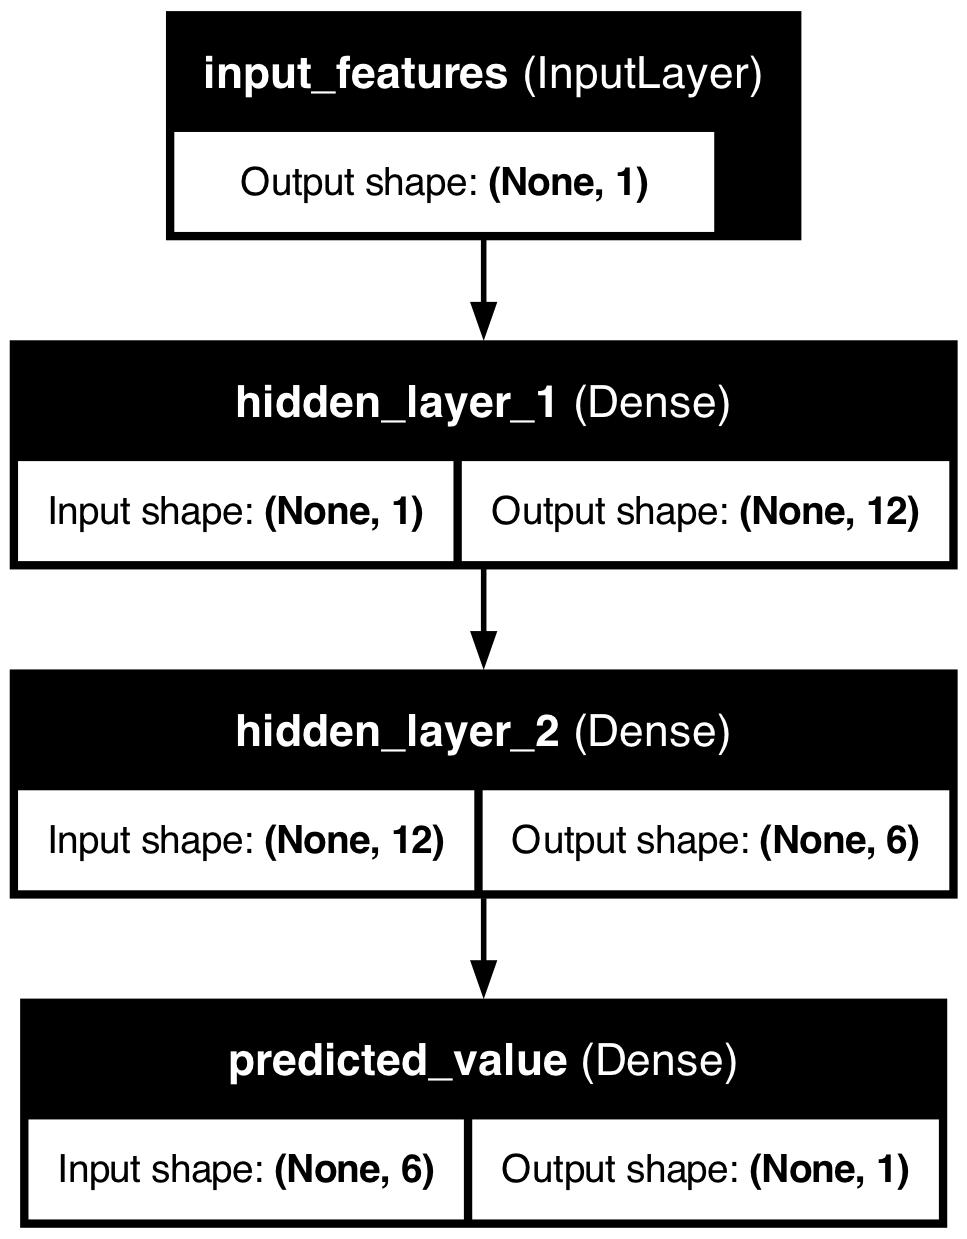

In [356]:
keras.utils.set_random_seed(random_state)
results = []

for file_path in DATASET_FILES:
    result = run_pipeline(file_path)
    results.append(result)

plot_all_results(results)
plot_all_losses(results)
print_results_summary(results)

keras.utils.plot_model(
    build_regression_model(),
    OUTPUT_DIR / "regression_model.png",
    show_shapes=True,
    show_layer_names=True
)
